<a href="https://colab.research.google.com/github/Maziger/Laksegate-master-thesis/blob/main/POC/tabicl_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TabICL experiment

code: https://github.com/soda-inria/tabicl?tab=readme-ov-file

paper: https://arxiv.org/abs/2602.11139

In [1]:
import os
from google.colab import userdata

user = "Maziger"
repo = "Laksegate-master-thesis"

# remove local directory if it already exists
if os.path.isdir(repo):
    !rm -rf {repo}

!git clone https://github.com/{user}/{repo}.git
%cd Laksegate-master-thesis/

!pip install -q tabicl

Cloning into 'Laksegate-master-thesis'...
remote: Enumerating objects: 364, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 364 (delta 25), reused 9 (delta 4), pack-reused 306 (from 2)
Receiving objects: 100% (364/364), 54.20 MiB | 13.30 MiB/s, done.
Resolving deltas: 100% (194/194), done.
/content/Laksegate-master-thesis
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.2/201.2 kB 10.0 MB/s eta 0:00:00


In [2]:
!pip install -q tabicl[forecast]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 121.2 MB/s eta 0:00:00


In [ ]:
# Optional
#!pip install tabicl[forecast]   # time series forecasting
#!pip install tabicl[pretrain]   # pre-training
#!pip install tabicl[all]        # everything

In [3]:
import pandas as pd
path = "POC/Forecasts_DE_DNN_LEAR_ensembles.csv"
data = pd.read_csv(path)
data = data[['Unnamed: 0', 'Real price']]
train = data[:14000]
test = data[14000:]

# Generic example

In [4]:
import pandas as pd
from tabicl import TabICLForecaster
from tabicl.forecast import TimeSeriesDataFrame, plot_forecast

df = pd.read_csv(
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/australian_electricity_subset/test.csv",
    parse_dates=["timestamp"],
)
data = TimeSeriesDataFrame.from_data_frame(df)

prediction_length = 96
selected_items = data.item_ids[:2]
train_data, test_data = data.train_test_split(prediction_length)

context_df = train_data.reset_index()
context_df = context_df[context_df["item_id"].isin(selected_items)]
test_df = test_data.reset_index()
test_df = test_df[test_df["item_id"].isin(selected_items)]
test_df = test_df.groupby("item_id").tail(prediction_length)


GPU 0::   0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Checkpoint 'tabicl-regressor-v2-20260212.ckpt' not cached.



tabicl-regressor-v2-20260212.ckpt:   0%|          | 0.00/114M [00:00<?, ?B/s]

GPU 0:: 100%|██████████| 2/2 [00:18<00:00,  9.19s/it]


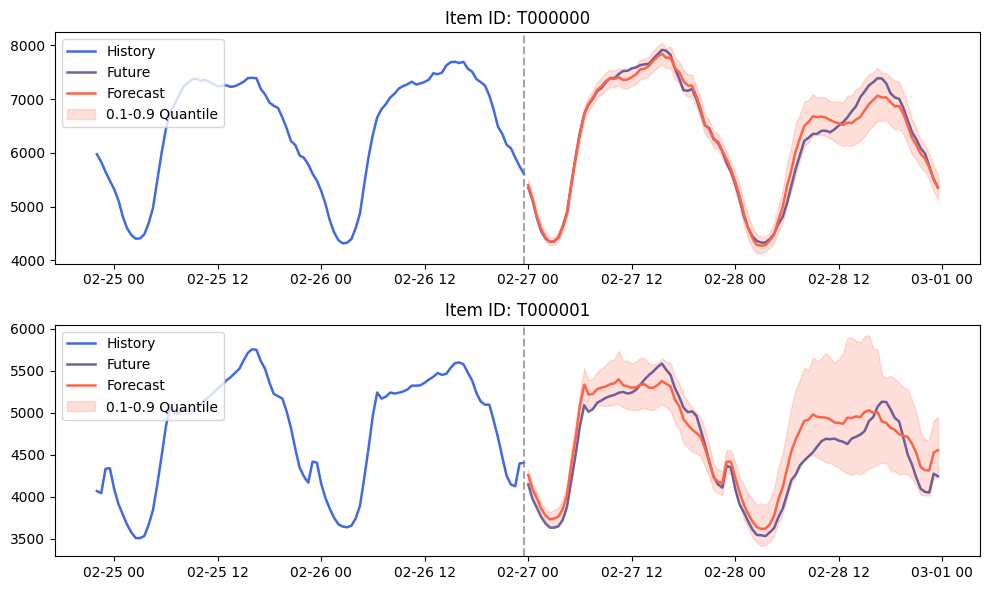

In [5]:
forecaster = TabICLForecaster(max_context_length=10240)
pred_df = forecaster.predict_df(context_df, prediction_length=prediction_length)
fig, axes = plot_forecast(context_df=context_df, pred_df=pred_df, test_df=test_df)

# Electricity price example

In [9]:
import pandas as pd
from tabicl import TabICLForecaster
from tabicl.forecast import TimeSeriesDataFrame, plot_forecast

df = pd.read_csv(
    "POC/Forecasts_DE_DNN_LEAR_ensembles.csv",
    parse_dates=["Unnamed: 0"],
)
df = df[['Unnamed: 0', 'Real price']]
df.columns = ['timestamp', 'target']
df['item_id'] = 0
data = TimeSeriesDataFrame.from_data_frame(df)

prediction_length = 72
selected_items = data.item_ids[:2]
train_data, test_data = data.train_test_split(prediction_length)

context_df = train_data.reset_index()
context_df = context_df[context_df["item_id"].isin(selected_items)]
test_df = test_data.reset_index()
test_df = test_df[test_df["item_id"].isin(selected_items)]
test_df = test_df.groupby("item_id").tail(prediction_length)

GPU 0:: 100%|██████████| 1/1 [00:04<00:00,  4.93s/it]


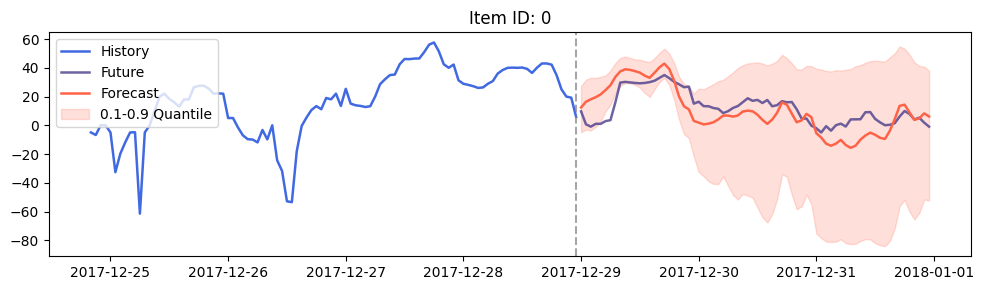

In [10]:
forecaster = TabICLForecaster(max_context_length=10240)
pred_df = forecaster.predict_df(context_df, prediction_length=prediction_length)
fig, axes = plot_forecast(context_df=context_df, pred_df=pred_df, test_df=test_df)

In [11]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Ensure test_df has a multi-index for alignment with pred_df
try:
    test_df_aligned = test_df.set_index(['item_id', 'timestamp'])
except KeyError:
    # If test_df already has 'item_id' and 'timestamp' as index, it will raise KeyError
    # In that case, we can use it directly or try to reset then set again for consistency
    # Given the previous cell's `reset_index()` and `groupby().tail()`, it should have columns.
    test_df_aligned = test_df.set_index(['item_id', 'timestamp'])

# Extract actual values from test_df
y_true = test_df_aligned['target']

# Extract predicted mean values from pred_df
y_pred = pred_df['target']

# Ensure both series are aligned (though they should be by construction)
# Using reindex to be safe, in case there are any mismatches in indices.
y_pred = y_pred.reindex(y_true.index)

# Calculate MAE and RMSE
mae = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

Mean Absolute Error (MAE): 9.176
Root Mean Squared Error (RMSE): 10.778


# Christoph Molnar code

*Note: this is a regression task, not forecasting*

https://mindfulmodeler.substack.com/p/a-regression-example-with-tabiclv2

In [ ]:
!pip install -q ucimlrepo

In [35]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
from sklearn.model_selection import train_test_split

energy = fetch_ucirepo(id=242)
X = energy.data.features
y = energy.data.targets["Y1"]  # Heating Load

X.columns = ["Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
    "Overall Height", "Orientation", "Glazing Area", "Glazing Area Distribution"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
X_train.head()

Train: 614 rows | Test: 154 rows


,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution
60,0.82,612.5,318.5,147.0,7.0,2,0.10,1
618,0.64,784.0,343.0,220.5,3.5,4,0.40,2
346,0.86,588.0,294.0,147.0,7.0,4,0.25,2
294,0.90,563.5,318.5,122.5,7.0,4,0.25,1
231,0.66,759.5,318.5,220.5,3.5,5,0.10,4


In [36]:
import time
from tabicl import TabICLRegressor
from sklearn.ensemble import RandomForestRegressor

tabicl = TabICLRegressor(n_estimators=8, device="cpu", random_state=42)
rf = RandomForestRegressor(random_state=42)

for name, model in [("TabICL", tabicl), ("RandomForest", rf)]:
    t0 = time.time()
    model.fit(X_train, y_train)
    print(f"{name:<12} fit: {time.time() - t0:.2f}s")

TabICL       fit: 0.80s
RandomForest fit: 0.64s


In [37]:
import numpy as np
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

results = {}
for name, model, kwargs in [
    ("TabICL",      tabicl, {"output_type": "mean"}),
    ("RandomForest", rf, {}),
]:
    t0 = time.time()
    y_pred = model.predict(X_test, **kwargs)
    results[name] = y_pred
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{name:<12}  RMSE={rmse:.3f}  MAE={mae:.3f}  predict={time.time()-t0:.2f}s")

TabICL        RMSE=0.424  MAE=0.304  predict=10.45s
RandomForest  RMSE=0.491  MAE=0.355  predict=0.02s


In [38]:
quantiles = tabicl.predict(X_test, output_type="quantiles", alphas=[0.05, 0.95])
coverage = np.mean((y_test.values >= quantiles[:, 0]) & (y_test.values <= quantiles[:, 1]))
print(f"Empirical 90% coverage: {coverage:.1%}")

Empirical 90% coverage: 90.9%


In [40]:
import shap

X_test_sample = X_test.iloc[:30]

def predict_fn(x):
    return tabicl.predict(pd.DataFrame(x, columns=X_train.columns), output_type="mean")

background = shap.sample(X_train, 50, random_state=42)
explainer = shap.PermutationExplainer(predict_fn, background)

# TabICL PermutationExplainer
t0 = time.time()
shap_values = explainer(X_test_sample)
print(f"SHAP completed in {time.time() - t0:.1f}s")

# RF TreeExplainer
t0 = time.time()
tree_explainer = shap.TreeExplainer(rf)
tree_explainer(X_test_sample)
print(f"TreeExplainer    (RF): {time.time() - t0:.3f}s")

# RF PermutationExplainer
t0 = time.time()
perm_explainer_rf = shap.PermutationExplainer(rf.predict, background)
perm_explainer_rf(X_test_sample)
print(f"PermutationExplainer (RF): {time.time() - t0:.1f}s")

shap.summary_plot(shap_values, X_test_sample, show=False)

KeyboardInterrupt: 